# Figure 1: Representative HH Graph and Period Input-Output Function

This notebook first explains how Figure 1 follows from the particular Liapunov&ndash;Schmidt reduced equations considered in the manuscript, then reproduces the representative HH graph and the graph of the corresponding Period Input-Output Function. Note that the analysis of the Liapunov&ndash;Schmidt reduced equations essentially mimics the proof of the main theorem in the manuscript. 

Recall from the caption of Figure 1 that the plots were produced from the Liapunov&ndash;Schmidt reduced equations by choosing 
$$
\begin{aligned}
p(r, \lambda, \mathcal{I}, \tau) &= \frac{1}{2}\mathcal{I}^2 + \lambda \mathcal{I} + \mathcal{I} + \lambda - r\\
q(r, \lambda, \mathcal{I}, \tau) &= -\frac{3}{4}\mathcal{I}^2 - \mathcal{I} - \lambda - \tau + r
\end{aligned}
$$

To see this is true, first solve the equation $q=0$ for $\tau$ as a function of the other variables. This yields
$$
\begin{aligned}
\tilde{T}(r, \lambda, \mathcal{I}) = -\frac{3}{4}\mathcal{I}^2 - \mathcal{I} - \lambda + r
\end{aligned}
$$

The next step is solving the equation $p= 0$ for $r$ as a function of the other variables. The result is
$$
\begin{aligned}
\tilde{Z}(\lambda, \mathcal{I}) = \frac{1}{2} \mathcal{I}^2 + \lambda \mathcal{I} + \mathcal{I} + \lambda
\end{aligned}
$$

Therefore, the period parameter $\tau$ is uniquely determined by the smooth function
$$
\begin{aligned}
T(\lambda, \mathcal{I}) &= \tilde{T}(\tilde{Z}(\lambda, \mathcal{I}), \lambda, \mathcal{I})\\
&=-\frac{1}{4}\mathcal{I}^2 + \lambda \mathcal{I}
\end{aligned}
$$

It follows that the IPH curve $\mathcal{S}$ is defined by 
$$
\begin{aligned}
0 &= T_{\mathcal{I}}(\lambda, \mathcal{I}) = -\frac{1}{2}\mathcal{I} + \lambda
\end{aligned}
$$
or
$$
\begin{aligned}
\mathcal{I}_{\text{S}}(\lambda) = 2\lambda
\end{aligned}
$$

Furthermore, the period is given by
$$
\begin{aligned}
P(\lambda, \mathcal{I}) &= \frac{2\pi}{1 + T(\lambda, \mathcal{I})}\\
&= \frac{2\pi}{1 - \frac{1}{4}\mathcal{I}^2 + \lambda \mathcal{I}}
\end{aligned}
$$

As for the Hopf curve $\mathcal{H}$, it follows from the nondegenerate Hopf theorem that the real part of the critical eigenvalues is
$$
\begin{aligned}
\sigma(\lambda, \mathcal{I}) &= p(0, \lambda, \mathcal{I}, T(\lambda, \mathcal{I}))\\
&= \frac{1}{2} \mathcal{I}^2 + (1 + \lambda)\mathcal{I} + \lambda
\end{aligned}
$$

This is a quadratic function of $\mathcal{I}$. The zero whose graph passes through the origin is $\mathcal{H}$, which is
$$
\begin{aligned}
\mathcal{I}_{\text{H}}(\lambda) &= - (1 + \lambda) + \sqrt{(1 + \lambda)^2 - 2\lambda}
\end{aligned}
$$

Lastly, note that $\sigma_{\lambda}(0) = 1$ and $p_{r}(0) = -1$. This implies that, for any $\mathcal{I}$, the reduced one-dimensional bifurcation equation is $\mathbf{Z}_2$-equivalent to the normal form $-x^3 + \lambda x$. In particular, the periodic regime lies to the right of $\mathcal{H}$.

The observations made above justify the construction of the the following plots. 

In [4]:
# import packages
import numpy as np
import matplotlib.pyplot as plt

## Figure 1a: Representative HH graph

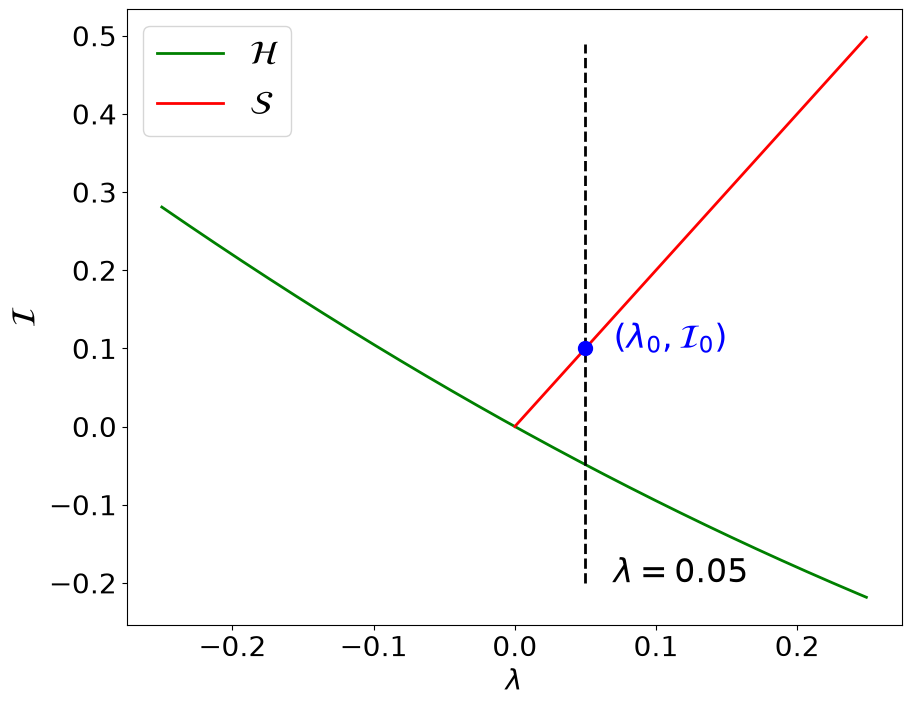

In [5]:
# define "implicit" functions
def I_hopf(lam):
    return -(1 + lam) + np.sqrt(lam ** 2 + 1)

def I_siph(lam):
    return 2 * lam

# plotting data
lam = np.arange(-0.25, 0.25, 0.001)
hopf = I_hopf(lam)
siph = I_siph(lam)
mask = siph >= hopf 
vline = np.arange(-0.2, 0.5, 0.01)


# plot
plt.figure(figsize = (10, 8))
plt.plot(lam, hopf, 'g-', linewidth = 2, label = r'$\mathcal{H}$')
plt.plot(lam[mask], siph[mask], 'r-', linewidth = 2, label = r'$\mathcal{S}$')
plt.plot(0.05 * np.ones(vline.shape), vline, 'k--', linewidth = 2)
plt.plot(0.05, I_siph(0.05), 'bo', markersize = 10)
plt.text(0.07, -0.2, r'$\lambda = 0.05$', c = 'k', fontsize = 24)
plt.text(0.07, I_siph(0.05), r'$(\lambda_0, \mathcal{I}_0)$', fontsize = 24, c = 'b')
plt.xlabel(r'$\lambda$', fontsize = 20)
plt.xticks(size = 20)
plt.ylabel(r'$\mathcal{I}$', fontsize = 24)
plt.yticks(size = 20)
plt.legend(loc = 'best', fontsize = 24)
plt.savefig("../outputs/figure1a.png", dpi = 300, bbox_inches = 'tight')
plt.show()

## Figure 1b: Graph of the Period Input-Output Function

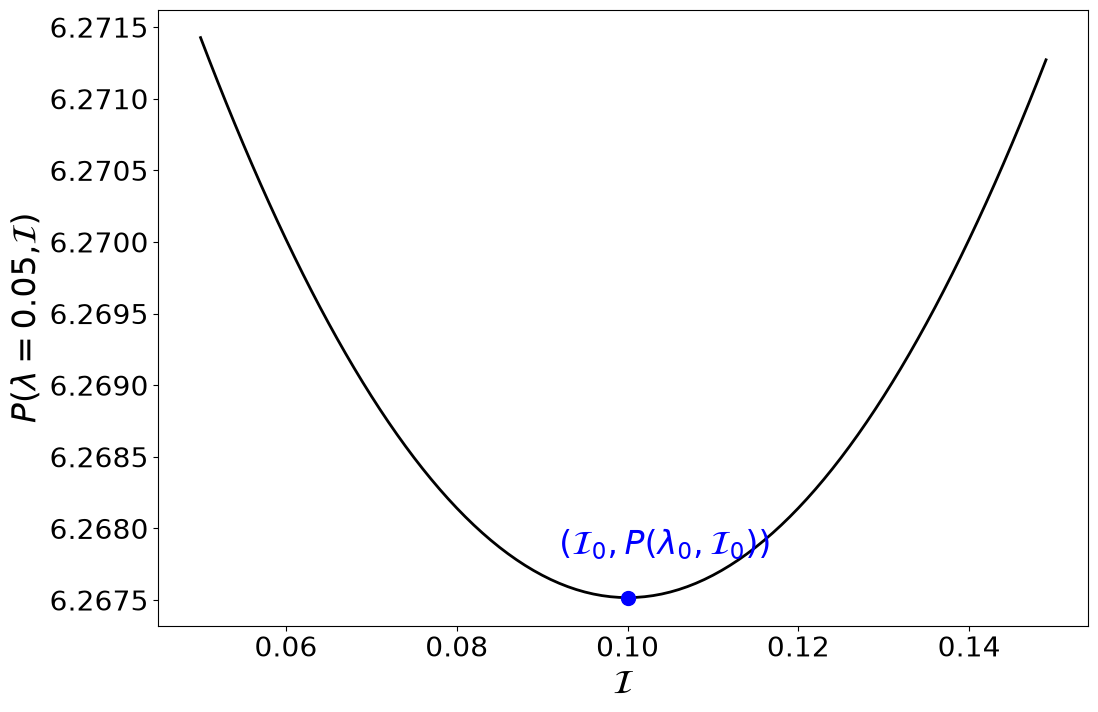

In [6]:
# define tau as a function of (lambda, I)
def tau(lam, I):
    return -I ** 2 / 4 + lam * I

# plotting data 
lam0 = 0.05 
I0 = 0.1
I = np.arange(0.05, 0.15, 0.001)
tau0 = tau(lam0, I)
period = 2 * np.pi / (1 + tau0)
period0 = 2 * np.pi / (1 + tau(lam0, I0))

# plot
plt.figure(figsize = (12, 8))
plt.plot(I, period, 'k-', linewidth = 2)
plt.plot(I0, period0, 'bo', markersize = 10)
plt.text(I0 - 0.008, period0 + 0.0003, r'$(\mathcal{I}_0, P(\lambda_0, \mathcal{I}_0))$', fontsize = 24, c = 'b')
plt.xlabel(r'$\mathcal{I}$', fontsize = 24)
plt.xticks(size = 20)
plt.ylabel(r'$P(\lambda = $' + f'{lam0},' + r'$ \mathcal{I})$', fontsize = 24)
plt.yticks(size = 20)
plt.savefig("../outputs/figure1b.png", dpi = 300, bbox_inches = 'tight')
plt.show()